In [1]:
# Cell 1 — Install & Imports
!pip install xgboost gradio PyGithub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports done. ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.1 MB/s eta 0:00:00
All imports done. ✅


In [13]:
# Cell 2 — Load & Explore Dataset
df = pd.read_csv('AI_vs_Human_Dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nLabel Distribution:\n{df['label'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Stats:")
df.describe()

Shape: (600, 11)

Label Distribution:
label
0    300
1    300
Name: count, dtype: int64

Missing Values:
commit_count                     0
avg_commit_message_length        0
commit_message_generic_score     0
code_comment_density             0
naming_convention_consistency    0
readme_complexity_score          0
ai_vocabulary_score              0
code_structure_uniformity        0
large_initial_commit             0
files_added_in_one_commit        0
label                            0
dtype: int64

Basic Stats:


,commit_count,avg_commit_message_length,commit_message_generic_score,code_comment_density,naming_convention_consistency,readme_complexity_score,ai_vocabulary_score,code_structure_uniformity,large_initial_commit,files_added_in_one_commit,label
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,127.641667,42.471167,0.518995,0.324951,0.721473,0.664409,0.469883,0.710131,0.511667,16.975000,0.500000
std,160.961510,18.005034,0.341225,0.198316,0.223079,0.259587,0.345303,0.235008,0.500281,14.998755,0.500417
min,1.000000,5.000000,0.000000,0.005000,0.252000,0.159000,0.000000,0.228000,0.000000,1.000000,0.000000
25%,3.000000,29.760000,0.195275,0.147950,0.514075,0.425500,0.137525,0.494075,0.000000,5.000000,0.000000
50%,14.000000,39.890000,0.571000,0.264500,0.779350,0.741500,0.436000,0.810500,1.000000,10.000000,0.500000
75%,244.250000,50.350000,0.840875,0.510775,0.924000,0.905000,0.799250,0.931075,1.000000,28.000000,1.000000
max,500.000000,90.500000,1.000000,0.786000,1.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000


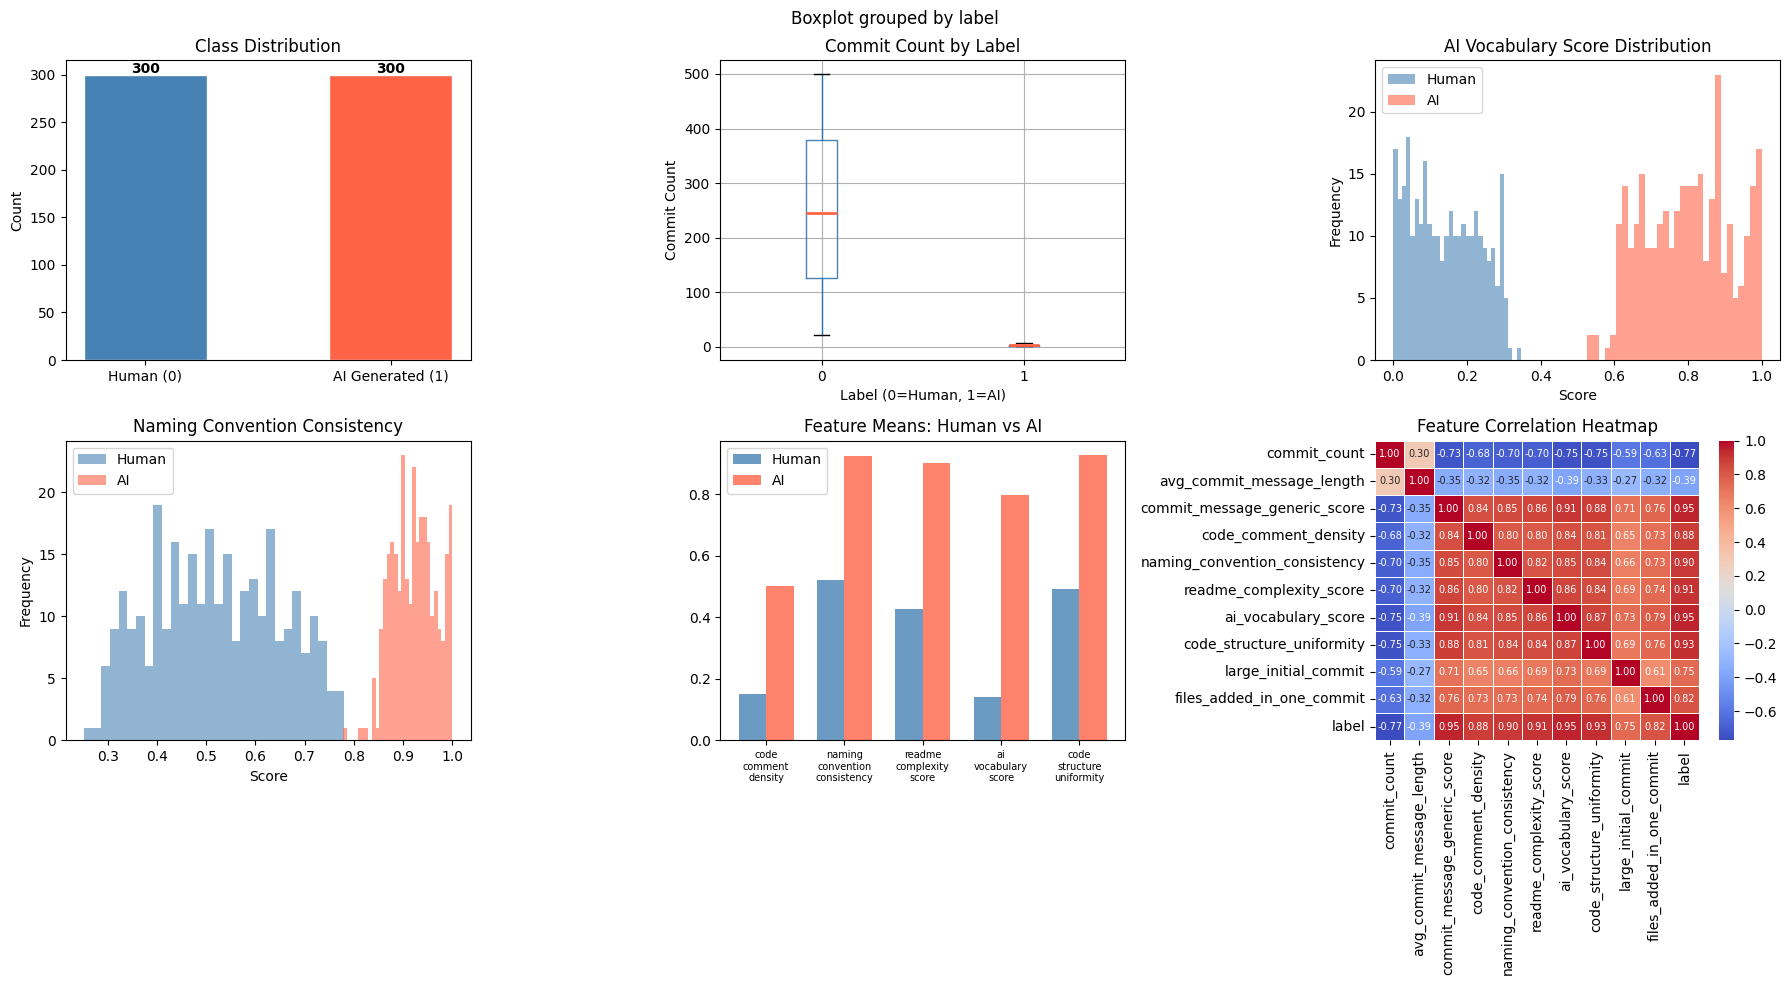

In [5]:
# Cell 3 — EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('AI Project Detector — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: Class Distribution ---
ax1 = axes[0, 0]
counts = df['label'].value_counts()
bars = ax1.bar(['Human (0)', 'AI Generated (1)'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
ax1.set_title('Class Distribution')
ax1.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2,
             str(val), ha='center', fontweight='bold')

# --- Plot 2: Commit Count by Label ---
ax2 = axes[0, 1]
df.boxplot(column='commit_count', by='label', ax=ax2,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
ax2.set_title('Commit Count by Label')
ax2.set_xlabel('Label (0=Human, 1=AI)')
ax2.set_ylabel('Commit Count')
plt.sca(ax2)
plt.title('Commit Count by Label')

# --- Plot 3: AI Vocabulary Score Distribution ---
ax3 = axes[0, 2]
df[df['label']==0]['ai_vocabulary_score'].plot(
    kind='hist', bins=30, alpha=0.6, color='steelblue', label='Human', ax=ax3)
df[df['label']==1]['ai_vocabulary_score'].plot(
    kind='hist', bins=30, alpha=0.6, color='tomato', label='AI', ax=ax3)
ax3.set_title('AI Vocabulary Score Distribution')
ax3.set_xlabel('Score')
ax3.legend()

# --- Plot 4: Naming Convention Consistency ---
ax4 = axes[1, 0]
df[df['label']==0]['naming_convention_consistency'].plot(
    kind='hist', bins=30, alpha=0.6, color='steelblue', label='Human', ax=ax4)
df[df['label']==1]['naming_convention_consistency'].plot(
    kind='hist', bins=30, alpha=0.6, color='tomato', label='AI', ax=ax4)
ax4.set_title('Naming Convention Consistency')
ax4.set_xlabel('Score')
ax4.legend()

# --- Plot 5: Feature Means Comparison ---
ax5 = axes[1, 1]
features = ['code_comment_density', 'naming_convention_consistency',
            'readme_complexity_score', 'ai_vocabulary_score',
            'code_structure_uniformity']
human_means = df[df['label']==0][features].mean()
ai_means = df[df['label']==1][features].mean()
x = np.arange(len(features))
width = 0.35
ax5.bar(x - width/2, human_means, width, label='Human', color='steelblue', alpha=0.8)
ax5.bar(x + width/2, ai_means, width, label='AI', color='tomato', alpha=0.8)
ax5.set_xticks(x)
ax5.set_xticklabels([f.replace('_', '\n') for f in features], fontsize=7)
ax5.set_title('Feature Means: Human vs AI')
ax5.legend()

# --- Plot 6: Correlation Heatmap ---
ax6 = axes[1, 2]
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax6, annot_kws={'size': 7}, linewidths=0.5)
ax6.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [6]:
# Cell 4 — Preprocessing & Train/Test Split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features: {list(X.columns)}")

Training samples: 480
Testing samples: 120
Features: ['commit_count', 'avg_commit_message_length', 'commit_message_generic_score', 'code_comment_density', 'naming_convention_consistency', 'readme_complexity_score', 'ai_vocabulary_score', 'code_structure_uniformity', 'large_initial_commit', 'files_added_in_one_commit']


In [7]:
# Cell 5 — Train Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained. ✅")

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost trained. ✅")

Random Forest trained. ✅
XGBoost trained. ✅


RANDOM FOREST
Accuracy: 1.0000
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        60
AI Generated       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

XGBOOST
Accuracy: 1.0000
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        60
AI Generated       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



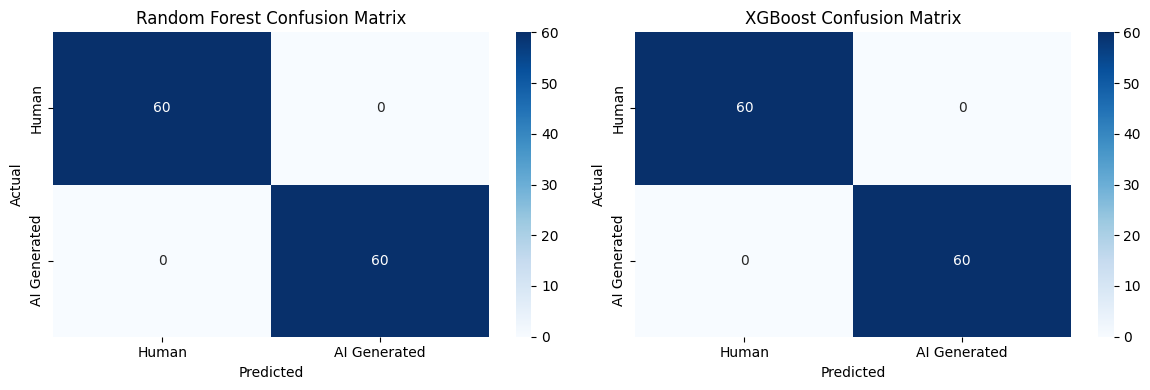

In [8]:
# Cell 6 — Evaluate & Compare Models
rf_pred = rf_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

print("=" * 45)
print("RANDOM FOREST")
print("=" * 45)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, target_names=['Human', 'AI Generated']))

print("=" * 45)
print("XGBOOST")
print("=" * 45)
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Human', 'AI Generated']))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes,
                            [rf_pred, xgb_pred],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI Generated'],
                yticklabels=['Human', 'AI Generated'])
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

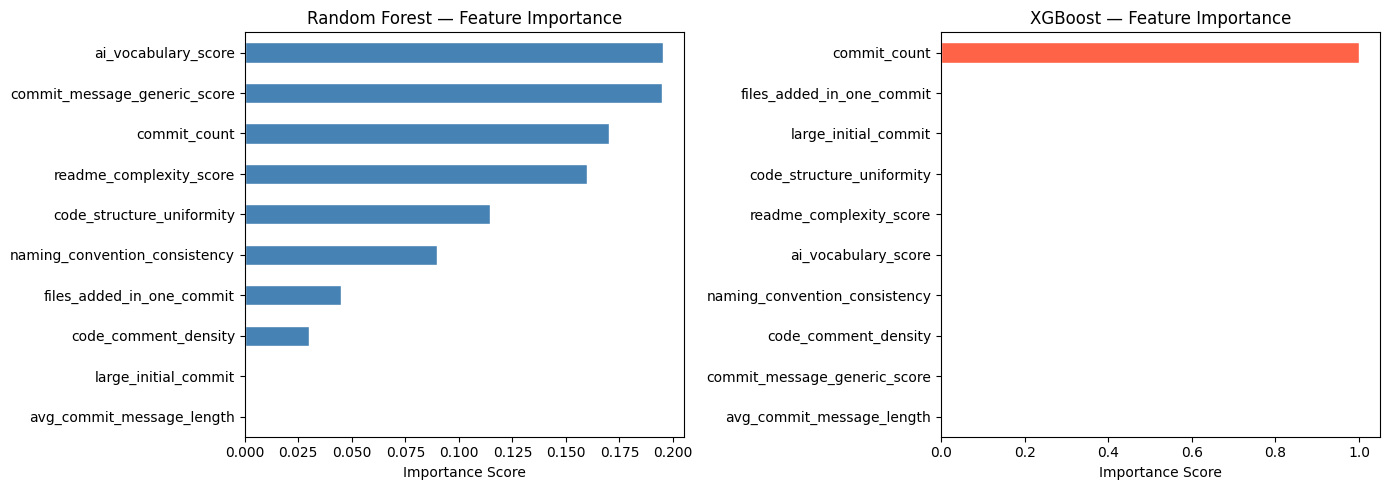

In [9]:
# Cell 7 — Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_names = list(X.columns)

# Random Forest Importance
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance Score')

# XGBoost Importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values()
xgb_importance.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [10]:
# Cell 8 — Save Models
import joblib

joblib.dump(rf_model, 'rf_ai_detector.pkl')
joblib.dump(xgb_model, 'xgb_ai_detector.pkl')
joblib.dump(scaler, 'scaler.pkl')

feature_names = list(X.columns)
joblib.dump(feature_names, 'feature_names.pkl')

print("Models saved. ✅")
print("Files: rf_ai_detector.pkl, xgb_ai_detector.pkl, scaler.pkl, feature_names.pkl")

Models saved. ✅
Files: rf_ai_detector.pkl, xgb_ai_detector.pkl, scaler.pkl, feature_names.pkl


In [12]:
# Cell 9 — Gradio Interface
import gradio as gr
import joblib
import numpy as np
import re

# Load models
rf_model = joblib.load('rf_ai_detector.pkl')
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl')

# ==========================================
# FEATURE EXTRACTION FROM CODE PASTE
# ==========================================

def extract_features_from_code(code):
    lines = code.split('\n')
    total_lines = max(len(lines), 1)

    # Comment density
    comment_lines = sum(1 for l in lines if l.strip().startswith('#') or l.strip().startswith('//'))
    code_comment_density = min(comment_lines / total_lines, 1.0)

    # AI vocabulary in comments
    ai_words = ['ensure', 'utilize', 'straightforward', 'leverage',
                'robust', 'seamlessly', 'efficiently', 'comprehensively',
                'streamline', 'facilitate', 'implement', 'initialize']
    comment_text = ' '.join(l for l in lines if l.strip().startswith('#') or l.strip().startswith('//')).lower()
    ai_vocab_hits = sum(1 for w in ai_words if w in comment_text)
    ai_vocabulary_score = min(ai_vocab_hits / max(len(ai_words), 1), 1.0)

    # Naming convention consistency
    identifiers = re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\b', code)
    snake = sum(1 for i in identifiers if '_' in i and i.islower())
    camel = sum(1 for i in identifiers if re.match(r'^[a-z]+[A-Z]', i))
    total_id = max(len(identifiers), 1)
    dominant = max(snake, camel)
    naming_convention_consistency = min(dominant / total_id * 2, 1.0)

    # Code structure uniformity — indentation consistency
    indented = [len(l) - len(l.lstrip()) for l in lines if l.strip()]
    if len(indented) > 1:
        indent_std = np.std(indented)
        code_structure_uniformity = max(0, 1 - indent_std / 20)
    else:
        code_structure_uniformity = 0.5

    # README complexity — approximate from code length and structure
    readme_complexity_score = min(len(code) / 5000, 1.0)

    # Commit-related — defaults for code paste (no git history)
    commit_count = 3
    avg_commit_message_length = 35.0
    commit_message_generic_score = 0.8
    large_initial_commit = 1
    files_added_in_one_commit = 20

    features = [
        commit_count,
        avg_commit_message_length,
        commit_message_generic_score,
        code_comment_density,
        naming_convention_consistency,
        readme_complexity_score,
        ai_vocabulary_score,
        code_structure_uniformity,
        large_initial_commit,
        files_added_in_one_commit
    ]

    return features

# ==========================================
# FEATURE EXTRACTION FROM GITHUB URL
# ==========================================

def extract_features_from_github(url):
    try:
        from github import Github
        import re

        # Parse owner/repo from URL
        match = re.search(r'github\.com/([^/]+)/([^/]+)', url)
        if not match:
            return None, "Invalid GitHub URL format."

        owner, repo_name = match.group(1), match.group(2).replace('.git', '')

        g = Github()  # unauthenticated — 60 req/hr
        repo = g.get_repo(f"{owner}/{repo_name}")

        # Commit analysis
        commits = list(repo.get_commits())
        commit_count = len(commits)

        messages = [c.commit.message for c in commits[:50]]
        avg_commit_message_length = np.mean([len(m) for m in messages]) if messages else 30

        generic_words = ['initial commit', 'add files', 'update', 'fix', 'first commit', 'upload']
        generic_count = sum(1 for m in messages if any(g in m.lower() for g in generic_words))
        commit_message_generic_score = min(generic_count / max(len(messages), 1), 1.0)

        # Large initial commit
        first_commit_files = len(list(commits[-1].files)) if commits else 0
        large_initial_commit = 1 if first_commit_files > 10 else 0
        files_added_in_one_commit = first_commit_files

        # README complexity
        try:
            readme = repo.get_readme()
            readme_content = readme.decoded_content.decode()
            readme_complexity_score = min(len(readme_content) / 3000, 1.0)
        except:
            readme_complexity_score = 0.2

        # Code features from default branch files
        ai_words = ['ensure', 'utilize', 'straightforward', 'leverage',
                    'robust', 'seamlessly', 'efficiently', 'comprehensively']
        ai_vocab_hits = 0
        comment_lines = 0
        total_lines = 0
        naming_scores = []

        contents = repo.get_contents("")
        py_files = [f for f in contents if f.name.endswith('.py') or f.name.endswith('.ipynb')][:3]

        for file in py_files:
            try:
                code = file.decoded_content.decode('utf-8', errors='ignore')
                lines = code.split('\n')
                total_lines += len(lines)
                comment_lines += sum(1 for l in lines if l.strip().startswith('#'))
                comment_text = ' '.join(l for l in lines if l.strip().startswith('#')).lower()
                ai_vocab_hits += sum(1 for w in ai_words if w in comment_text)
                identifiers = re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\b', code)
                snake = sum(1 for i in identifiers if '_' in i and i.islower())
                total_id = max(len(identifiers), 1)
                naming_scores.append(min(snake / total_id * 2, 1.0))
            except:
                continue

        code_comment_density = min(comment_lines / max(total_lines, 1), 1.0)
        ai_vocabulary_score = min(ai_vocab_hits / max(len(ai_words), 1), 1.0)
        naming_convention_consistency = np.mean(naming_scores) if naming_scores else 0.5
        code_structure_uniformity = 0.7 if large_initial_commit else 0.4

        features = [
            commit_count,
            avg_commit_message_length,
            commit_message_generic_score,
            code_comment_density,
            naming_convention_consistency,
            readme_complexity_score,
            ai_vocabulary_score,
            code_structure_uniformity,
            large_initial_commit,
            files_added_in_one_commit
        ]

        return features, None

    except Exception as e:
        return None, f"Error: {str(e)}"

# ==========================================
# PREDICTION ENGINE
# ==========================================

def predict(features):
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    probability = rf_model.predict_proba(features_scaled)[0]
    return prediction, probability

def build_output(features, prediction, probability):
    ai_pct = round(probability[1] * 100)
    human_pct = round(probability[0] * 100)
    verdict = "🚨 AI GENERATED" if prediction == 1 else "✅ HUMAN MADE"

    feature_report = "\n".join([
        f"• {name.replace('_', ' ').title()}: {round(val, 3)}"
        for name, val in zip(feature_names, features)
    ])

    confidence = f"Human: {human_pct}%  {'█' * (human_pct // 5)}{'░' * (20 - human_pct // 5)}\nAI:    {ai_pct}%  {'█' * (ai_pct // 5)}{'░' * (20 - ai_pct // 5)}"

    return feature_report, confidence, verdict

# ==========================================
# GRADIO HANDLERS
# ==========================================

def analyze_code(code):
    if not code.strip():
        return "", "", "Please paste some code."
    features = extract_features_from_code(code)
    prediction, probability = predict(features)
    return build_output(features, prediction, probability)

def analyze_github(url):
    if not url.strip():
        return "", "", "Please enter a GitHub URL."
    features, error = extract_features_from_github(url)
    if error:
        return "", "", f"Error: {error}"
    prediction, probability = predict(features)
    return build_output(features, prediction, probability)

# ==========================================
# GRADIO INTERFACE
# ==========================================

with gr.Blocks(title="AI Project Detector") as demo:
    gr.Markdown("# AI Project Detector")
    gr.Markdown("Detect whether a GitHub project or code was generated by AI or written by a human.")

    with gr.Tabs():
        with gr.Tab("GitHub URL"):
            url_input = gr.Textbox(
                lines=1,
                placeholder="https://github.com/username/repository",
                label="GitHub Repository URL"
            )
            url_btn = gr.Button("Analyze Repository")
            with gr.Row():
                url_features = gr.Textbox(label="Extracted Features", lines=12)
                url_confidence = gr.Textbox(label="Confidence", lines=3)
            url_verdict = gr.Textbox(label="Final Verdict", lines=2)
            url_btn.click(analyze_github,
                         inputs=url_input,
                         outputs=[url_features, url_confidence, url_verdict])

        with gr.Tab("Code Paste"):
            code_input = gr.Code(
                language="python",
                label="Paste Your Code Here",
                lines=15
            )
            code_btn = gr.Button("Analyze Code")
            with gr.Row():
                code_features = gr.Textbox(label="Extracted Features", lines=12)
                code_confidence = gr.Textbox(label="Confidence", lines=3)
            code_verdict = gr.Textbox(label="Final Verdict", lines=2)
            code_btn.click(analyze_code,
                          inputs=code_input,
                          outputs=[code_features, code_confidence, code_verdict])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d81ba53c5d610abcf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
